In [1]:
%cd ../../

/home/hoanghu/projects/fw-models


In [2]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and resources

In [4]:
path = "data/processed/phase_4/dim_pieces_per_dish.xlsx"
pos = pl.read_excel(path)
pos.head()

date,restaurant,meal_type,pcs,meal_id
date,str,str,i64,i64
2023-01-02,"""che""","""fish""",78,9500055
2023-01-02,"""che""","""vegan""",84,6128
2023-01-02,"""che""","""meat""",165,9500160
2023-01-03,"""che""","""vegetarian""",29,1270
2023-01-03,"""che""","""fish""",105,6156


In [5]:
meals = pl.read_excel("data/processed/phase_4/dim_meals.xlsx")
meals.head()

meal_id,meal_type_1,schoolyear,is_kela,is_new,restaurant,meal_type_2,pcs_mean
i64,str,str,bool,bool,str,str,f64
9017,"""vegan""","""24-25""",true,true,"""che-exa-vik""","""vegan-miscellaneous""",116.3425
7201,"""vegan""","""23-24""",false,false,null,null,106.231119
9032,"""vegan""","""23-24""",false,false,null,null,106.231119
9102,"""vegan""","""23-24""",false,false,null,null,106.231119
7010,"""vegetarian""","""24-25""",false,false,"""che-exa-vik""",null,71.0


In [6]:
meal_names = pl.read_excel("data/processed/phase_4/dim_meal_names.xlsx")
meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


In [7]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


In [8]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pd.read_csv(path, delimiter=';')
    df.columns = np.arange(df.shape[1])
    raw.append(df)


pos_raw = pd.concat(raw, ignore_index=True)
pos_raw.head()

/tmp/ipykernel_31496/1467303410.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, delimiter=';')


,0,1,2,3,4,5,6
0,2.1.2023,10:31,600 Chemicum,Liha,"Uunimakkaraa,sinappikastiketta",1,"0,9"
1,2.1.2023,10:32,600 Chemicum,Kala,Kalapuikot tillikermaviilikast,1,"1,04"
2,2.1.2023,10:32,600 Chemicum,Liha,"Uunimakkaraa,sinappikastiketta",1,"0,9"
3,2.1.2023,10:35,600 Chemicum,Kala,Kalapuikot tillikermaviilikast,1,"1,04"
4,2.1.2023,10:36,600 Chemicum,Liha,"Uunimakkaraa,sinappikastiketta",2,"1,8"


In [9]:
pos = pos_raw.copy()


# Rename columns
pos.columns = np.arange(pos.shape[1])
pos.rename(
    columns={
        0: 'date',
        1: 'time',
        2: 'restaurant',
        3: 'meal_type',
        4: 'meal',
        5: 'pcs',
        6: 'co2',
    },
    inplace=True
)


# Convert pcs
def _f_conv(s):
    match s:
        case int() | float():
            return float(s)
        case str():
            if re.search(r'\s', s) is None:
                return float(s)
            return np.nan

pos['pcs'] = pos['pcs'].apply(_f_conv)
pos = pos[~pos['pcs'].isna()]


# Map restaurant name
pos['restaurant'] = pos['restaurant'].map({
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
})


# Process date
pos['datetime'] = pd.to_datetime(pos['date'] + " " + pos['time'], format="%d.%m.%Y %H:%M")
pos.drop(columns=['date', 'time'], inplace=True)

# Process meal_type
pos['meal_type'] = pos['meal_type'].map({
    'Liha': 'meat',
    'Kala': 'fish',
    'Vegaani': 'vegan',
    'Kasvis': 'vegetarian',
    'Kana': 'chicken'
})


# Process meal
pos['meal'] = pos['meal'].str.strip()


# Remove 'take away' meals
pos = pos[~pos['meal'].str.lower().str.contains('take away')]


pos = pl.from_dataframe(pos)
pos = pos.join(meal_names, on='meal', how='inner').drop('co2', 'meal', 'meal_type')
pos.head()


restaurant,pcs,datetime,meal_id
str,f64,datetime[ns],i64
"""che""",1.0,2023-01-02 10:31:00,9500160
"""che""",1.0,2023-01-02 10:32:00,9500055
"""che""",1.0,2023-01-02 10:32:00,9500160
"""che""",1.0,2023-01-02 10:35:00,9500055
"""che""",2.0,2023-01-02 10:36:00,9500160


In [10]:
# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove POS of leftover
DELTA = 3
pos = (
    pos
    # .filter((pl.col('meal_id') == 1317) & (pl.col('restaurant') == pl.lit('che')))
    .with_columns(
        pl.col('date').shift(1).over('meal_id', 'restaurant', order_by='date').alias('date_prev')
    )
    .sort('date')
    .filter(
        ((pl.col('date') - pl.col('date_prev')).dt.total_days() > DELTA)
        | (pl.col('date_prev').is_null())
    )
    .drop('date_prev')
)




# Filter out dates having low serving_percent ( < 50% )
MIN_SERV_PERCENT = .5
pos_rmv = pos.filter(pl.col('serving_percent') >= MIN_SERV_PERCENT)




# Remove redundant columns
pos = pos.select('restaurant', 'date', 'meal_id', 'pcs')
pos_rmv = pos_rmv.select('restaurant', 'date', 'meal_id', 'pcs')

pos.head()

restaurant,date,meal_id,pcs
str,date,i64,f64
"""che""",2023-01-02,9500160,165.0
"""che""",2023-01-02,6128,84.0
"""che""",2023-01-02,9500055,78.0
"""che""",2023-01-03,9500164,51.0
"""che""",2023-01-03,9500117,17.0


In [11]:
# path = "data/processed/phase_4/dim_pieces_per_dish_tmp.xlsx"

# pos.join(meals.select('meal_id', pl.col('meal_type_1').alias('meal_type')), on='meal_id', how='left').write_excel(path)

# Analyze

## Analyze all meals in all restaurant

In [14]:
(
    pos_rmv
    .filter((pl.col('meal_id') == 9500132) & (pl.col('restaurant') == pl.lit('exa')))
)

restaurant,date,meal_id,pcs
str,date,i64,f64
"""exa""",2023-03-08,9500132,53.0


In [16]:
meal_types = meals.select('meal_id', pl.col('meal_type_1').alias('meal_type'))

meal_types.head()

meal_id,meal_type
i64,str
9017,"""vegan"""
7201,"""vegan"""
9032,"""vegan"""
9102,"""vegan"""
7010,"""vegetarian"""


In [20]:
pos_std = (
    pos
    .group_by('restaurant', 'meal_id')
    .agg(
        pl.col('pcs').std().alias('std')
    )
    .filter(pl.col('std').is_not_null())
    .join(meal_types, on='meal_id', how='left')
)

pos_rmv_std = (
    pos_rmv
    .group_by('restaurant', 'meal_id')
    .agg(
        pl.col('pcs').std().alias('std')
    )
    .filter(pl.col('std').is_not_null())
    .join(meal_types, on='meal_id', how='left')
)

pos_std.head()

restaurant,meal_id,std,meal_type
str,i64,f64,str
"""phy""",1447,0.353553,"""vegetarian"""
"""exa""",9500155,20.305993,"""vegetarian"""
"""vik""",6859,72.053452,"""vegan"""
"""exa""",6674,28.02142,"""vegan"""
"""exa""",1317,59.250075,"""meat"""


<Axes: xlabel='meal_type', ylabel='std'>

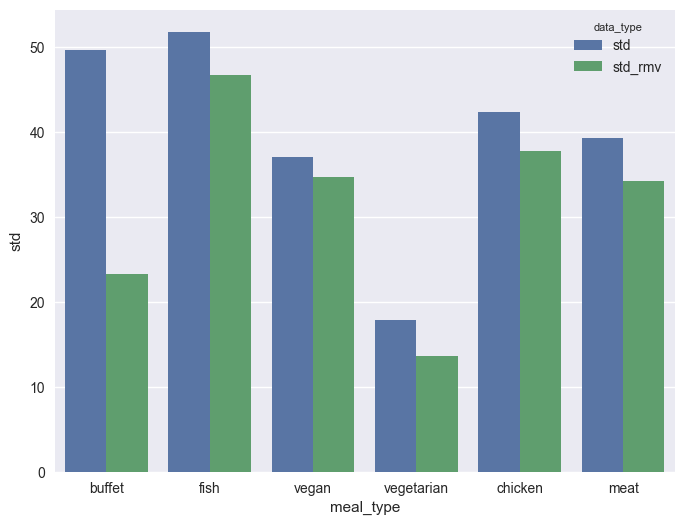

In [32]:
by_meal_type = pos_std.group_by('meal_type').agg(pl.col('std').mean())
by_meal_type_rmv = pos_rmv_std.group_by('meal_type').agg(pl.col('std').mean().alias('std_rmv'))

std = (
    by_meal_type
    .join(by_meal_type_rmv, on='meal_type')
    .unpivot(on=['std', 'std_rmv'], index='meal_type', variable_name='data_type', value_name='std')
)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(std, x='meal_type', y='std', hue='data_type', ax=ax)

<Axes: xlabel='restaurant', ylabel='std'>

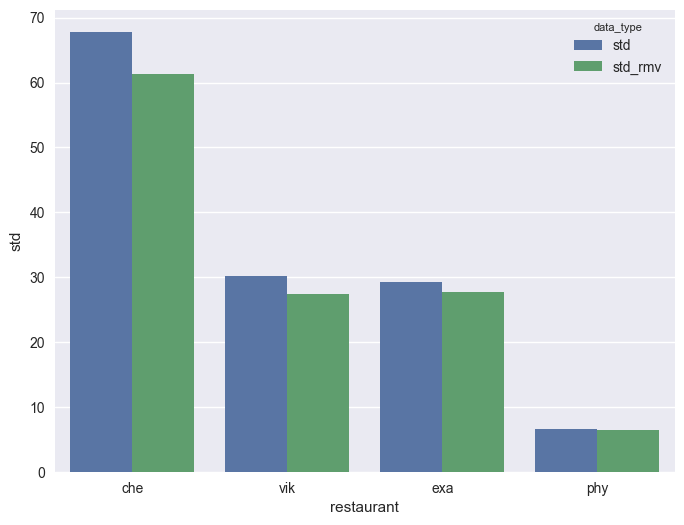

In [34]:
by_restaurant = pos_std.group_by('restaurant').agg(pl.col('std').mean())
by_restaurant_rmv = pos_rmv_std.group_by('restaurant').agg(pl.col('std').mean().alias('std_rmv'))

std = (
    by_restaurant
    .join(by_restaurant_rmv, on='restaurant')
    .unpivot(on=['std', 'std_rmv'], index='restaurant', variable_name='data_type', value_name='std')
)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(std, x='restaurant', y='std', hue='data_type', ax=ax)

## Analyze meal: 'Lihapullat &Kermaista Dijonk'

In [35]:
meal_names.filter(pl.col('meal_id') == 1317)

meal_id,meal
i64,str
1317,"""lihapullat & kermaista Dijonka…"
1317,"""Lihapullat &Kermaista Dijonkas…"


In [36]:
pos_1317_chemicum = pos.filter((pl.col('meal_id') == 1317) & (pl.col('restaurant') == 'che'))
pos_1317_chemicum.head()

restaurant,date,meal_id,pcs
str,date,i64,f64
"""che""",2023-01-04,1317,197.0
"""che""",2023-01-20,1317,19.0
"""che""",2023-02-06,1317,532.0
"""che""",2023-02-16,1317,90.0
"""che""",2023-03-06,1317,379.0


In [15]:
pos_1317_chemicum_unusual = (
    pos_1317_chemicum
    .filter(pl.col('pcs') < 50)
    .with_columns(
        (pl.col('serving_percent') < .5).alias('low_percent')
    )
)

pos_1317_chemicum_unusual.sort('date', descending=True)

restaurant,date,meal_id,pcs,time_start,time_end,serving_duration,working_duration,serving_percent,low_percent
str,date,i64,f64,datetime[ns],datetime[ns],f64,f64,f64,bool
"""che""",2023-12-07,1317,35.0,2023-12-07 11:42:00,2023-12-07 14:19:00,2.616667,4.5,0.581481,false


/tmp/ipykernel_116066/3329150218.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pos_1317_chemicum_unusual.select('serving_percent'), ax=ax)


<Axes: ylabel='Density'>

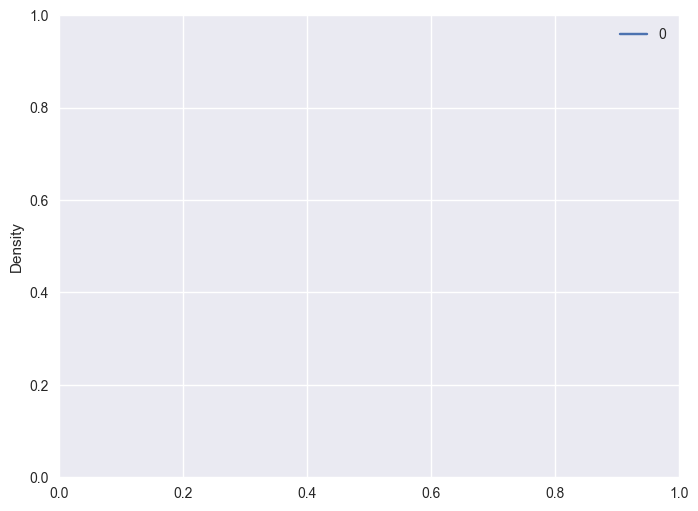

In [16]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)


sns.kdeplot(pos_1317_chemicum_unusual.select('serving_percent'), ax=ax)

<Axes: title={'center': "POS for meal 'Lihapullat &Kermaista Dijonkastiketta' in Chemicum | 'red' indicates unusual POS"}, xlabel='date', ylabel='pcs'>

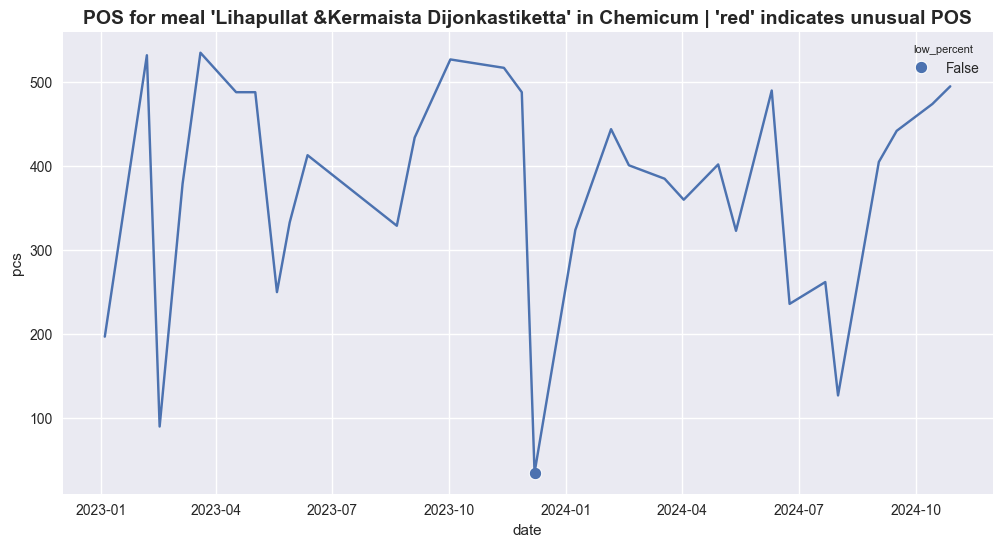

In [18]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
ax.set_title("POS for meal 'Lihapullat &Kermaista Dijonkastiketta' in Chemicum | 'red' indicates unusual POS", fontdict={'weight': 'bold', 'size': 14})

sns.lineplot(pos_1317_chemicum, x='date', y='pcs', ax=ax)
sns.scatterplot(pos_1317_chemicum_unusual, x='date', y='pcs', ax=ax, hue='low_percent', s=80)